## blakechart

In [1]:
from MatlabRadar import *

freq = 100e6
ant_height = 20
rng_fs = 100
vcp, vcpangles = radarvcd(freq, rng_fs, ant_height)
blakechart(vcp, vcpangles)

print("Done")

ValueError: Data must be 1-dimensional, got ndarray of shape (1, 1372) instead

## range2height

Text(0.5, 1.0, 'Target Height Estimation')

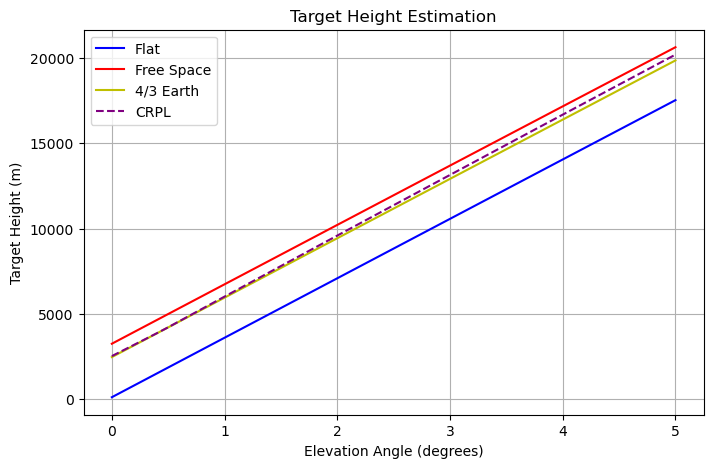

In [2]:
from MatlabRadar import *

R = 200e3
anht = 100
el = np.arange(0, 5.1, 0.1)
tgthtFlat = range2height(R, anht, el, method = "Flat")
r0 = Rearth
tgthtFS = range2height(R, anht, el, method = "Curved", Re = r0)
tgthtEffRad = range2height(R, anht, el)
tgthtCRPL = range2height(R, anht, el, method = "CRPL")

plt.figure(figsize=(8, 5))

plt.plot(el, tgthtFlat, color = 'b', linewidth = 1.5, label = "Flat")
plt.plot(el, tgthtFS, color = 'r', linewidth = 1.5, label = "Free Space")
plt.plot(el, tgthtEffRad, color = 'y', linewidth = 1.5, label = "4/3 Earth")
plt.plot(el, tgthtCRPL, '--', color = 'purple', linewidth = 1.5, label = "CRPL")
plt.grid(True)

plt.xlabel("Elevation Angle (degrees)")
plt.ylabel("Target Height (m)")
plt.legend()
plt.title("Target Height Estimation")

## radarmetricplot

(0.0, 40.0)

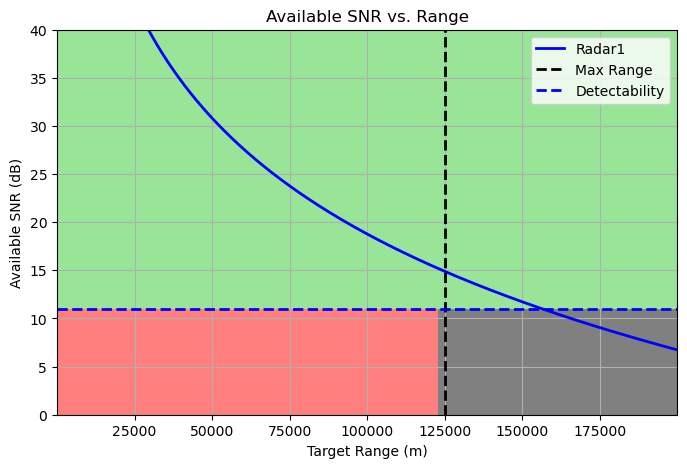

In [3]:
from MatlabRadar import *

wv, _ = freq2wavelen(3e9)             # Wavelength (m)
Pt = 5e3                              # Peak power (W)
tau = 1.2e-5                          # Pulse width (s)
N = 24                                # Number of received pulses
SwerlingCase = 'Swerling1'            # Swerling case
G = 40                                # Antenna gain (dB)
Pfa = 1e-6                            # Pfa

Pd = 0.9                              # Required Pd
MaxRangeRq = 125e3                    # Maximum range requirement (m)

R = list(range(1, int(200e3), int(1e2)))

SNRav = radareqsnr(wv, R, Pt, tau, Gain = G)

DxObj = detectability(Pd, Pfa, N, SwerlingCase)

h = radarmetricplot(
    R,
    SNRav,
    objective = DxObj,
    MaxRangeRequirement = MaxRangeRq,
    MetricName = 'Available SNR',
    MetricUnit = 'dB',
    RequirementName = 'Detectability',
    ShowStoplight = True,
)
h.set_ylim([0, 40])


## rocinterp

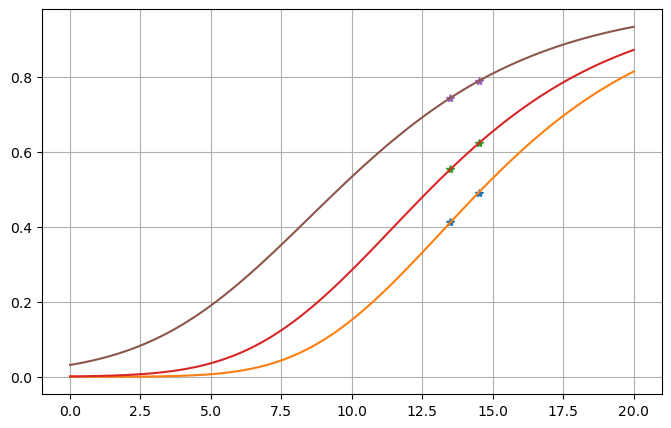

In [4]:
from MatlabRadar import *

SNR = [13.5, 14.5]
Pfa = [1e-9, 1e-6, 1e-3]

output_pd, output_snr = rocpfa(Pfa, SignalType = 'Swerling1')

ipd = rocinterp(output_snr, output_pd, SNR, 'snr-pd')

plt.figure(figsize=(8, 5))

for part, pd in zip(output_pd, ipd):
    plt.plot(SNR, pd, '*')
    plt.plot(output_snr, part)
    plt.grid(True)

## detectability

[11.86468299 12.53936352]


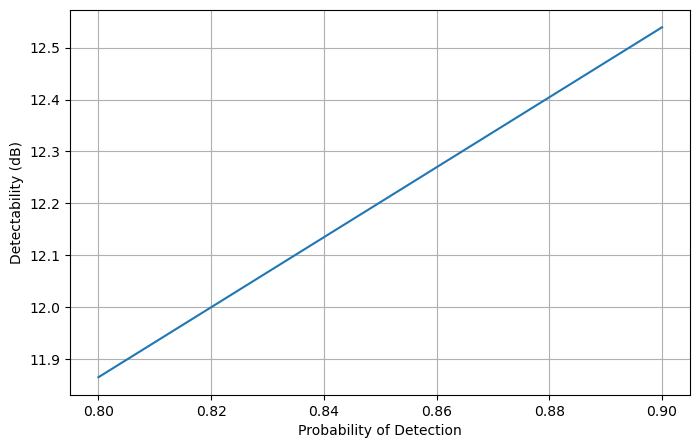

In [5]:
from MatlabRadar import *

PFA = 1e-5
PD = [0.8, 0.9]
N = 1
D = detectability(PD, PFA, N, 'Swerling0')
print(D)

plt.figure(figsize=(8, 5))
plt.plot(PD, D)
plt.xlabel('Probability of Detection')
plt.ylabel('Detectability (dB)')
plt.grid(True)


## tropopl

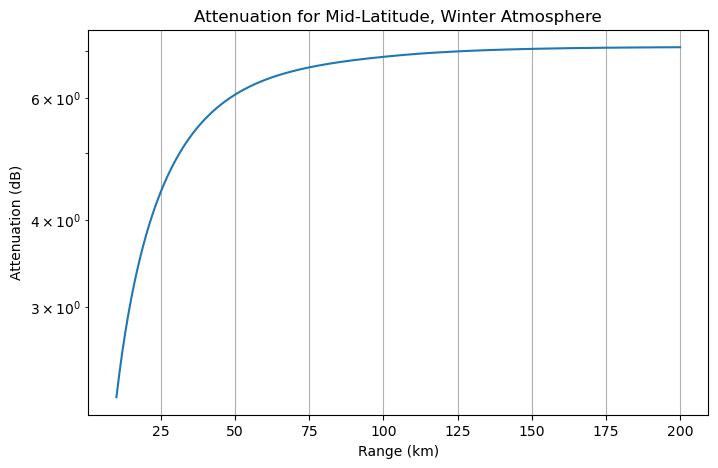

In [6]:
from MatlabRadar import *

R  = np.array(list(range(10, 200 + 1))) * 1e3      # m
f  = 100e9             # Hz
ht = 0                 # m
el = 5                 # deg
Lgas, _ = tropopl(R, f, ht, el, LatitudeModel = 'Mid', Season = 'Winter')

# Create the semilogy plot
plt.figure(figsize=(8, 5))
plt.semilogy(R * 1e-3, Lgas)

# Add labels and a title
plt.title('Attenuation for Mid-Latitude, Winter Atmosphere')
plt.xlabel('Range (km)')
plt.ylabel('Attenuation (dB)')
plt.grid(True)

# Display the plot
plt.show()

## lenspl

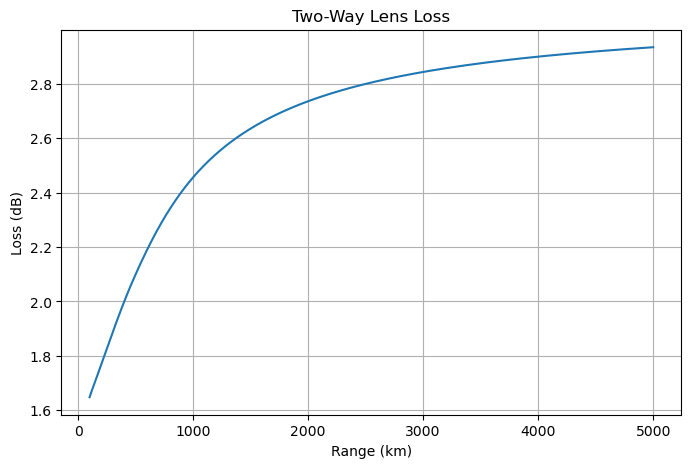

In [7]:
from MatlabRadar import *

h = 0 # m
el = 0.03 # deg 
R = np.array(list(range(100, 5000 + 1))) * 1e3 # m
L = 2 * lenspl(R, h, el) # Factor of 2 for two-way propagation

plt.figure(figsize=(8, 5))
plt.plot(R * 1e-3, L)
 
plt.xlabel('Range (km)')
plt.ylabel('Loss (dB)')
plt.title('Two-Way Lens Loss')
plt.grid(True)


## probgrid

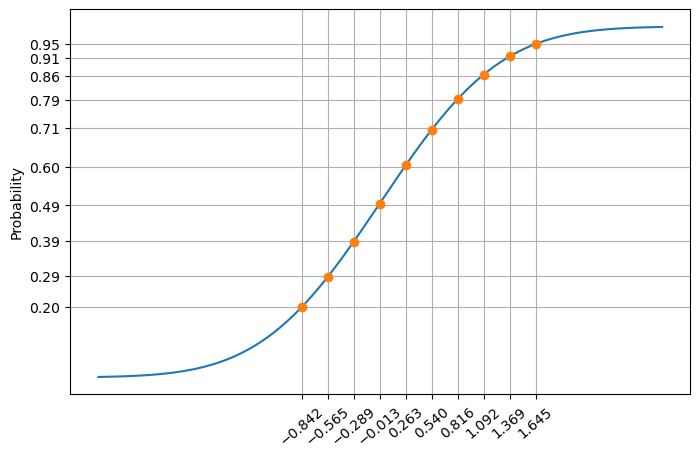

In [8]:
from MatlabRadar import *

pmin = 0.2
pmax = 0.95
N = 10

pd = probgrid(pmin, pmax, N)

xd = sqrt(2) * erfinv(2 * pd - 1)

x = np.arange(-3, 3, 0.01)
sncdf = (1 + erf(x / sqrt(2))) / 2

plt.figure(figsize=(8, 5))
plt.plot(x, sncdf)

plt.plot(xd, pd, 'o')

# legend({'Standard Normal CDF','Probability Vector'}, ...
#   'Location','Northwest')
plt.xticks(xd, rotation = 40)
plt.yticks(np.round(100 * pd) / 100)
plt.ylabel('Probability')
plt.grid(True)


## radarpropfactor

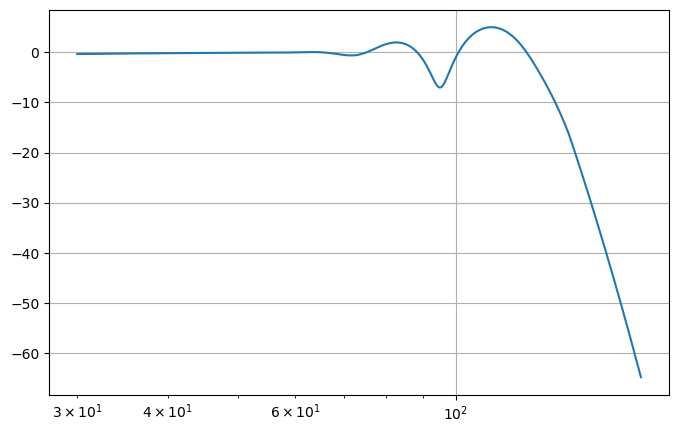

In [9]:
from MatlabRadar import *

R     = np.arange(30, 180.5, 0.5) * 1e3 # Range (m)
freq  = 3e9              # Frequency (Hz)
anht  = 10               # Radar height (m)
tgtht = 1e3              # Target height (m)
hgtsd = 1                # Height standard deviation (m)
beta0 = 0.05             # Surface slope (deg)

FdB = radarpropfactor(R, freq, anht, tgtht, htsd = hgtsd, beta0 = beta0)

plt.figure(figsize=(8, 5))
plt.semilogx(np.sort(np.ravel(R)) * 1e-3, FdB)
plt.grid(True)


## marcumq

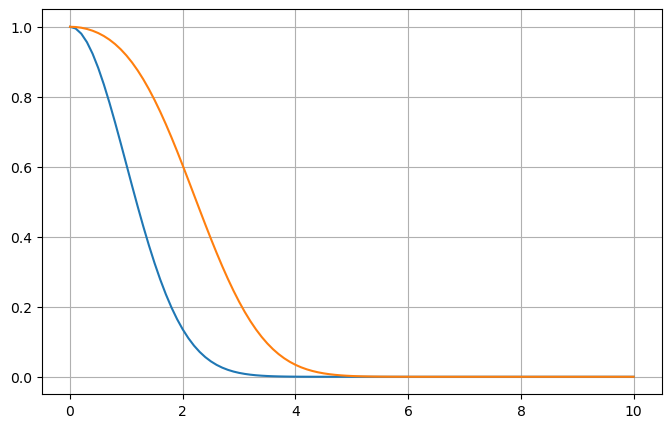

In [10]:
from MatlabRadar import *

b = np.arange(0, 10.1, 0.1)
Q1 = marcumq(0, b)
Q2 = marcumq(2, b)

plt.figure(figsize=(8, 5))
plt.plot(b, Q1, b, Q2)
plt.grid(True)


## besseli

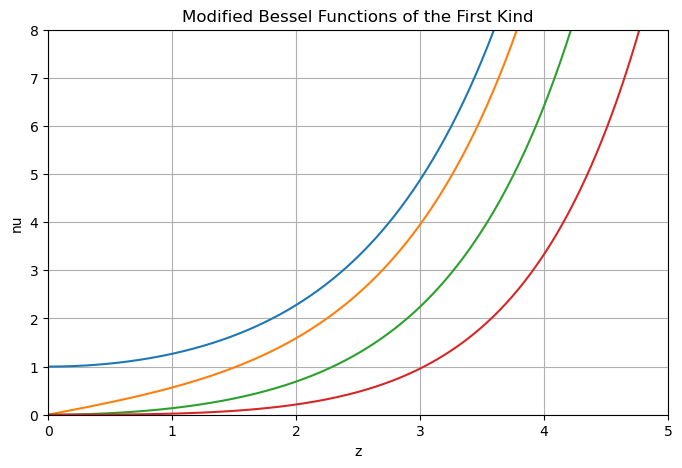

In [11]:
from MatlabRadar import *

z = np.arange(0, 5.01, 0.01)

plt.figure(figsize = (8, 5))
I = zeros((5, 501))
for nu in range(0, 4):
    I[nu, :] = besseli(nu, z)
    plt.plot(z, I[nu, :])

plt.xlim(0, 5)
plt.ylim(0, 8)
# grid on
# legend('I_0','I_1','I_2','I_3','I_4','Location','NorthWest')
plt.title('Modified Bessel Functions of the First Kind')
plt.xlabel('z')
plt.ylabel('nu')
plt.grid(True)
